<a href="https://colab.research.google.com/github/Eliekh2/MSBA-Projects/blob/main/EDA_Nigerian_Banking_Mobile_Money.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import pandas as pd
import numpy as np
# from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# electricsheepafrica/nigerian-banking-mobile-money
df_mobile_money = pd.read_parquet(
    "https://huggingface.co/datasets/electricsheepafrica/nigerian-banking-mobile-money/resolve/main/nigerian_mobile_money_full.parquet"
)

In [3]:
# Quick peek df_mobile_money
print(f"Dataset shape: {df_mobile_money.shape}")
print(f"\nColumns: {list(df_mobile_money.columns)}")
df_mobile_money.head()

Dataset shape: (4000000, 13)

Columns: ['transaction_id', 'wallet_id', 'timestamp', 'transaction_type', 'amount_ngn', 'fee_ngn', 'balance_after_ngn', 'agent_id', 'channel', 'device_os', 'kyc_tier', 'fraud_flag', 'churn_30d']


,transaction_id,wallet_id,timestamp,transaction_type,amount_ngn,fee_ngn,balance_after_ngn,agent_id,channel,device_os,kyc_tier,fraud_flag,churn_30d
0,90e956c0-7e3e-4207-8bbc-90de4c61d05e,WLT-00001530,2024-06-03 20:35:00,airtime,1000.0,10.0,917.204594,,ussd,android,tier2,False,False
1,3cff1814-4796-4e7e-91ff-2cc1240fe8d8,WLT-00001003,2024-04-01 08:34:00,cashin,1150.0,10.0,644.741704,AGT-00004700,ussd,android,tier2,False,False
2,9fb30da5-5e4e-453f-86cc-3cf842d211ac,WLT-00018460,2024-01-08 19:17:00,cashout,4850.0,10.0,3582.585292,AGT-00001615,app,android,tier1,False,False
3,6127f44f-6d23-4d9f-988f-54dcae598f4d,WLT-00000072,2024-04-14 23:10:00,p2p_send,9800.0,98.0,1546.044463,,ussd,android,tier3,False,False
4,f5ca608d-9ddb-40ca-a4ad-39c8474477cd,WLT-00017907,2024-06-14 07:10:00,billpay,1600.0,10.0,4361.698947,,app,feature_phone,tier2,False,False


In [4]:
# Check for missing values (NaN)
missing_values = df_mobile_money.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)


Missing values in each column:
transaction_id       0
wallet_id            0
timestamp            0
transaction_type     0
amount_ngn           0
fee_ngn              0
balance_after_ngn    0
agent_id             0
channel              0
device_os            0
kyc_tier             0
fraud_flag           0
churn_30d            0
dtype: int64


In [5]:
# Check for EMPTY strings
empty_string_counts = (df_mobile_money == '').sum()
print("\nEmpty strings in each column:")
print(empty_string_counts)


Empty strings in each column:
transaction_id             0
wallet_id                  0
timestamp                  0
transaction_type           0
amount_ngn                 0
fee_ngn                    0
balance_after_ngn          0
agent_id             3278910
channel                    0
device_os                  0
kyc_tier                   0
fraud_flag                 0
churn_30d                  0
dtype: int64


In [6]:
# Check for duplicates
duplicate_count = df_mobile_money.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


In [7]:
# Check for duplicate wallet_ids
duplicate_wallet_ids = df_mobile_money['wallet_id'].duplicated().sum()
print(f"\nNumber of duplicate wallet_ids: {duplicate_wallet_ids}")


Number of duplicate wallet_ids: 3624163


## Initial Data Overview

Get a comprehensive overview of the dataset, including data types, non-null values, and descriptive statistics for both numerical and categorical columns to understand the basic structure and characteristics of the data.

In [8]:
df_mobile_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000000 entries, 0 to 3999999
Data columns (total 13 columns):
 #   Column             Dtype         
---  ------             -----         
 0   transaction_id     object        
 1   wallet_id          object        
 2   timestamp          datetime64[ns]
 3   transaction_type   object        
 4   amount_ngn         float64       
 5   fee_ngn            float64       
 6   balance_after_ngn  float64       
 7   agent_id           object        
 8   channel            object        
 9   device_os          object        
 10  kyc_tier           object        
 11  fraud_flag         bool          
 12  churn_30d          bool          
dtypes: bool(2), datetime64[ns](1), float64(3), object(7)
memory usage: 343.3+ MB


In [9]:
# Describe statistics of numerical columns
df_mobile_money.describe()

,timestamp,amount_ngn,fee_ngn,balance_after_ngn
count,4000000,4.000000e+06,4.000000e+06,4.000000e+06
mean,2024-03-31 14:28:19.668344832,5.011743e+03,3.431395e+01,1.334904e+04
min,2024-01-01 00:01:00,5.000000e+01,1.000000e+01,4.479525e+01
25%,2024-02-15 10:33:00,7.500000e+02,1.000000e+01,4.126032e+03
50%,2024-03-31 15:18:00,1.650000e+03,1.000000e+01,8.096005e+03
75%,2024-05-15 18:29:00,4.300000e+03,1.000000e+01,1.588577e+04
max,2024-06-29 23:59:00,5.000000e+05,2.000000e+02,1.192877e+06
std,NaN,1.312389e+04,5.227146e+01,1.746935e+04


In [10]:
# Describe statistics of categorical columns
df_mobile_money.describe(include='object')

,transaction_id,wallet_id,transaction_type,agent_id,channel,device_os,kyc_tier
count,4000000,4000000,4000000,4000000,4000000,4000000,4000000
unique,4000000,375837,7,10000,4,3,3
top,82732838-4c10-41f4-b02a-66944b065ae8,WLT-00000001,airtime,,ussd,android,tier1
freq,1,100005,998117,3278910,2002912,2799711,2340195


In [11]:
# Replace empty strings in 'agent_id' with 'Not Applicable'
# Normalize empty strings → NaN
df_mobile_money['agent_id'] = df_mobile_money['agent_id'].replace('', np.nan)

# Create explicit category for missing agent_id, filling NaN with 'Not Applicable'
df_mobile_money['agent_id_clean'] = df_mobile_money['agent_id'].fillna('Not Applicable')

df_mobile_money['agent_id_clean'].value_counts(dropna=False)

,count
agent_id_clean,
Not Applicable,3278910
AGT-00005275,104
AGT-00009528,103
AGT-00006640,103
AGT-00003497,103
...,...
AGT-00007255,47
AGT-00003391,47
AGT-00007418,46


## Analyze Transaction Types

Explore the distribution of different 'transaction_type' values, including their frequencies and potentially their relationship with transaction amounts or other key metrics, using appropriate visualizations like bar charts.

In [12]:
# Analyze distribution of transaction types
transaction_type_counts = df_mobile_money['transaction_type'].value_counts()
print(transaction_type_counts)

transaction_type
airtime        998117
p2p_send       800456
p2p_receive    799343
billpay        600375
cashin         400789
cashout        320301
data            80619
Name: count, dtype: int64


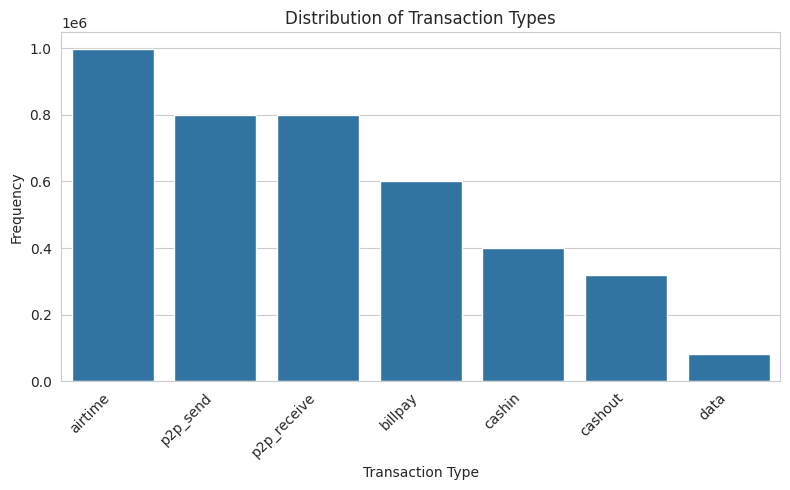

Bar plot showing the distribution of transaction types displayed.


In [13]:
# Visualize distribution of transaction types
plt.figure(figsize=(8, 5))
sns.barplot(x=transaction_type_counts.index, y=transaction_type_counts.values)
plt.title('Distribution of Transaction Types')
plt.xlabel('Transaction Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Bar plot showing the distribution of transaction types displayed.")

In [14]:
# Compare average and median transaction amounts by transaction type
comparison = df_mobile_money.groupby('transaction_type')['amount_ngn'].agg(['mean', 'median'])
print(comparison)

                         mean  median
transaction_type                     
airtime           1039.511099  1000.0
billpay           6471.105143  2450.0
cashin            6478.141616  2450.0
cashout           6481.863622  2450.0
data              1039.808234  1000.0
p2p_receive       6477.866948  2450.0
p2p_send          6483.736957  2450.0


While median values are identical across most transaction types, mean values vary slightly, indicating the presence of higher-value transactions affecting certain categories more than others.

<Figure size 800x500 with 0 Axes>

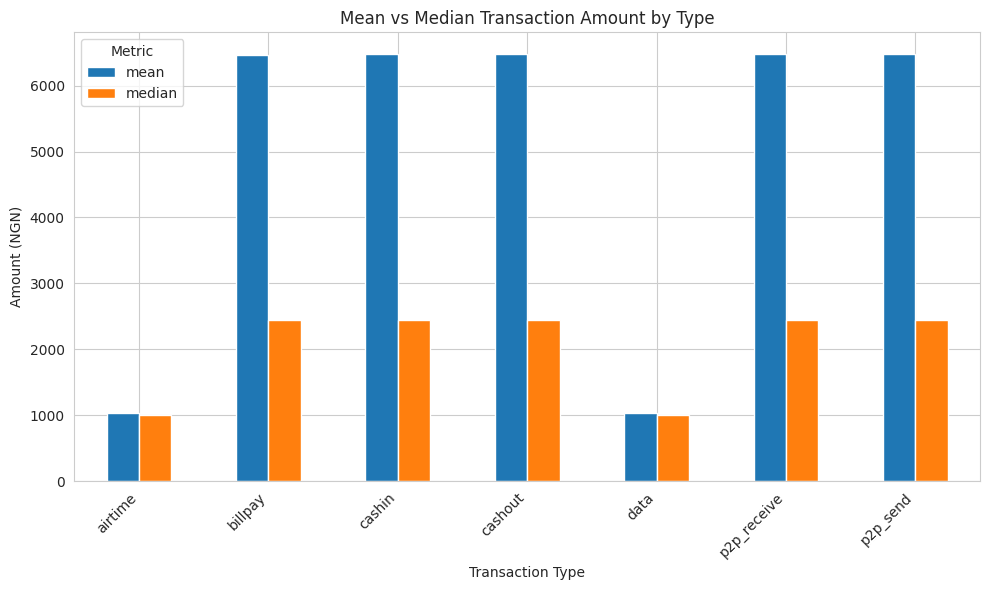

In [15]:
plt.figure(figsize=(8,5))

comparison.plot(kind='bar')

plt.title('Mean vs Median Transaction Amount by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Amount (NGN)')
plt.xticks(rotation=45, ha='right')

plt.legend(title='Metric')
plt.tight_layout()
plt.show()

While median transaction amounts are nearly identical across most transaction types, mean values vary slightly. This indicates that although typical transactions are consistent, certain transaction types include higher-value transactions that increase the average.

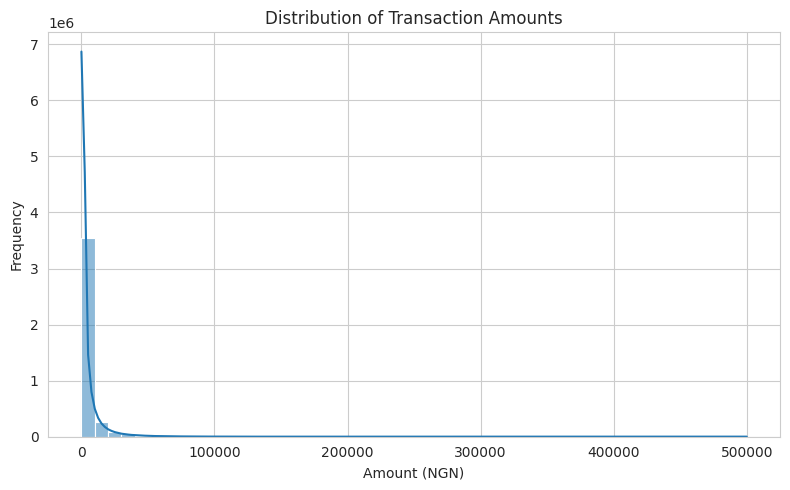

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df_mobile_money['amount_ngn'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount (NGN)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

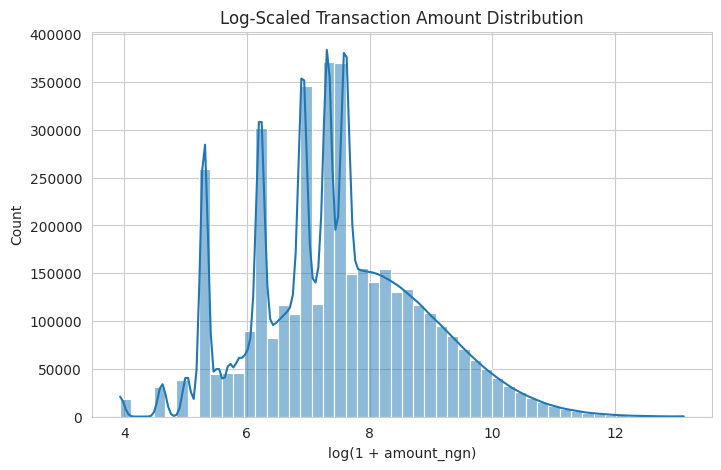

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_mobile_money['amount_ngn']), bins=50, kde=True)
plt.title('Log-Scaled Transaction Amount Distribution')
plt.xlabel('log(1 + amount_ngn)')
plt.show()

After applying a log transformation, the distribution reveals multiple distinct peaks rather than a smooth curve. This indicates that transaction amounts are concentrated around specific values, suggesting the presence of predefined transaction tiers or commonly used denominations.

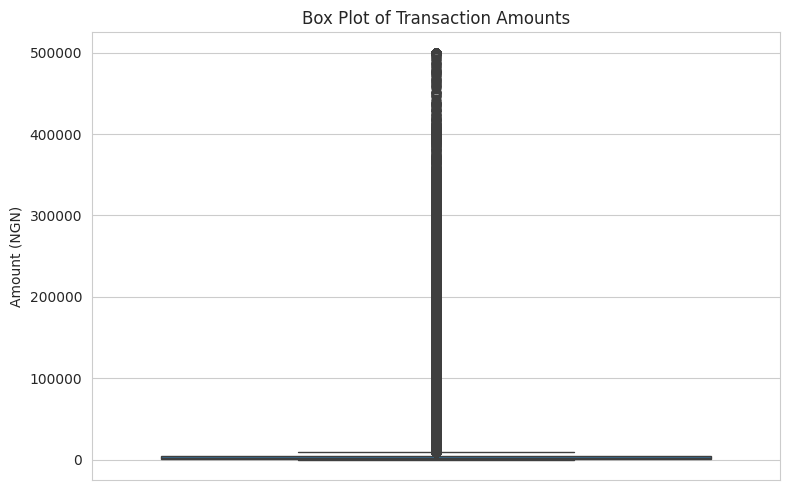

In [18]:
# Box plot for transaction amounts
plt.figure(figsize=(8, 5))
sns.boxplot(y=df_mobile_money['amount_ngn'])
plt.title('Box Plot of Transaction Amounts')
plt.ylabel('Amount (NGN)')
plt.tight_layout()
plt.show()

In [19]:
q1 = df_mobile_money['amount_ngn'].quantile(0.25)
q3 = df_mobile_money['amount_ngn'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

outliers = df_mobile_money[df_mobile_money['amount_ngn'] > upper_bound]

print(f"Outliers count: {len(outliers)}")

Outliers count: 477971


A large number of observations are flagged as outliers using the IQR method. However, this is due to the highly right-skewed nature of the data rather than data quality issues. Many high-value transactions are legitimate and should not be treated as anomalies.

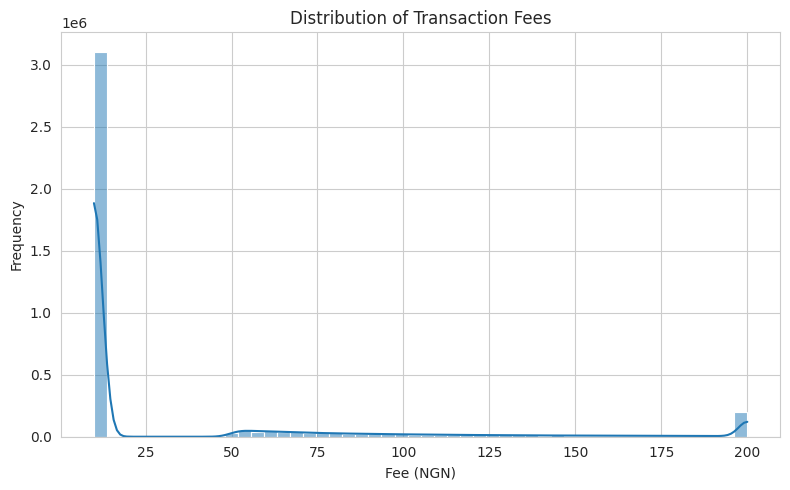

In [20]:
# Analyze distribution of transaction fees
plt.figure(figsize=(8, 5))
sns.histplot(df_mobile_money['fee_ngn'], bins=50, kde=True)
plt.title('Distribution of Transaction Fees')
plt.xlabel('Fee (NGN)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

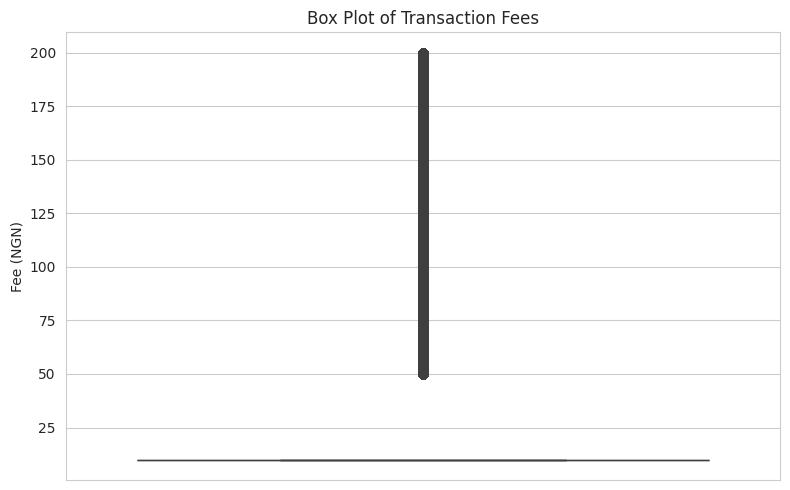

In [21]:
# Box plot for transaction fees
plt.figure(figsize=(8, 5))
sns.boxplot(y=df_mobile_money['fee_ngn'])
plt.title('Box Plot of Transaction Fees')
plt.ylabel('Fee (NGN)')
plt.tight_layout()
plt.show()

The distribution of transaction fees is highly right-skewed, with a strong concentration around low values (~10 NGN). Additionally, the presence of distinct peaks at higher values suggests that fees are applied in discrete tiers rather than as a continuous function of transaction amount.

This tiered structure in fees aligns with the earlier observation that transaction amounts are also concentrated at specific values, suggesting that the pricing model may be based on predefined transaction brackets.

## Analyze Amount and Fee Distributions

Examine the distributions of 'amount_ngn' and 'fee_ngn' using histograms and box plots to identify their ranges, central tendencies, and spread, as well as detect any outliers.

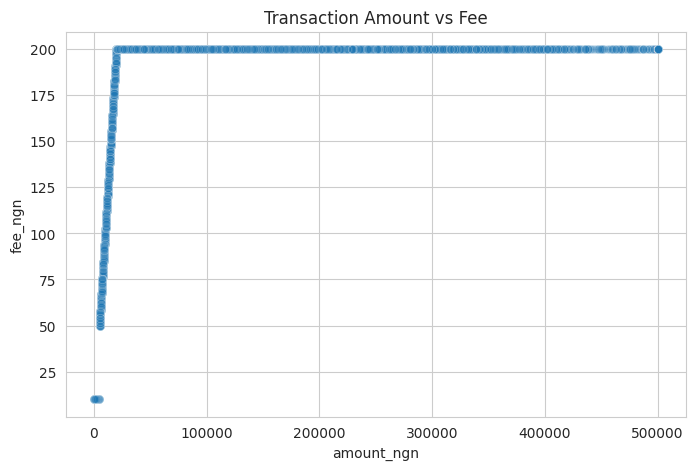

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_mobile_money, x='amount_ngn', y='fee_ngn', alpha=0.2)
plt.title('Transaction Amount vs Fee')
plt.show()

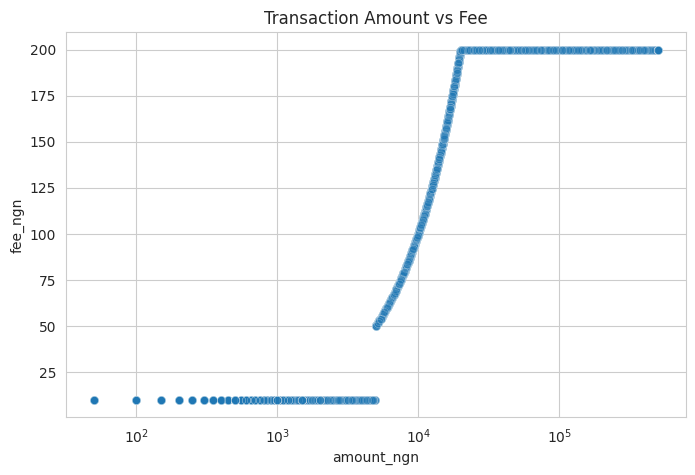

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_mobile_money, x='amount_ngn', y='fee_ngn', alpha=0.2)
plt.title('Transaction Amount vs Fee')
plt.xscale('log')
plt.show()

Using a logarithmic scale for transaction amounts reveals a clear piecewise relationship between amount and fees. For low transaction values, fees remain nearly constant at a minimal level (~10 NGN), indicating a flat fee tier. As transaction amounts increase, fees rise sharply within a specific range, suggesting a transition between pricing brackets. Beyond a certain threshold, fees stabilize at an upper cap (~200 NGN), remaining constant despite further increases in transaction amount. This confirms a tiered, non-linear pricing model with both minimum and maximum fee boundaries.

In [24]:
# Analyze frequency of each channel
channel_counts = df_mobile_money['channel'].value_counts()
print("Frequency of each channel:")
print(channel_counts)

channel_percent = (channel_counts / len(df_mobile_money)) * 100

print("\nPercentage distribution of each channel:")
print(channel_percent.round(2))

Frequency of each channel:
channel
ussd     2002912
app      1399243
agent     518296
web        79549
Name: count, dtype: int64

Percentage distribution of each channel:
channel
ussd     50.07
app      34.98
agent    12.96
web       1.99
Name: count, dtype: float64


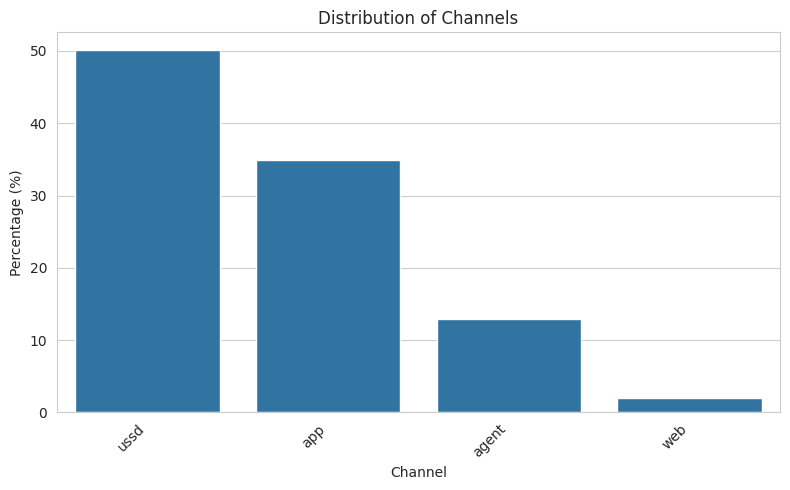

In [25]:
# Visualize distribution of channels
plt.figure(figsize=(8, 5))
sns.barplot(x=channel_percent.index, y=channel_percent.values)
plt.title('Distribution of Channels')
plt.xlabel('Channel')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The distribution of transaction channels is highly imbalanced, with USSD accounting for approximately 50% of all transactions, followed by the mobile app at around 35%. Agent-based transactions represent a smaller share (~13%), while web usage is negligible (~2%).

This pattern indicates a strongly mobile-centric ecosystem, where users predominantly rely on USSD and app interfaces for financial transactions. The dominance of USSD suggests that accessibility and compatibility with basic mobile devices remain critical, while the substantial share of app usage reflects growing adoption of smartphone-based services.

The limited use of web channels further reinforces that transactions are primarily conducted through mobile platforms rather than desktop environments, highlighting the importance of mobile-first system design in this context.

## Explore Channel and Device OS Usage

Investigate the usage patterns across different 'channel' and 'device_os' categories. This will involve counting the occurrences of each category and visualizing them to understand user behavior and preferences.

In [26]:
# Analyze frequency of each device OS
device_os_counts = df_mobile_money['device_os'].value_counts()
print("Frequency of each device OS:")
print(device_os_counts)

device_os_percent = (device_os_counts / len(df_mobile_money)) * 100
print("\nPercentage distribution of each device OS:")
print(device_os_percent.round(2))

Frequency of each device OS:
device_os
android          2799711
feature_phone    1000110
ios               200179
Name: count, dtype: int64

Percentage distribution of each device OS:
device_os
android          69.99
feature_phone    25.00
ios               5.00
Name: count, dtype: float64


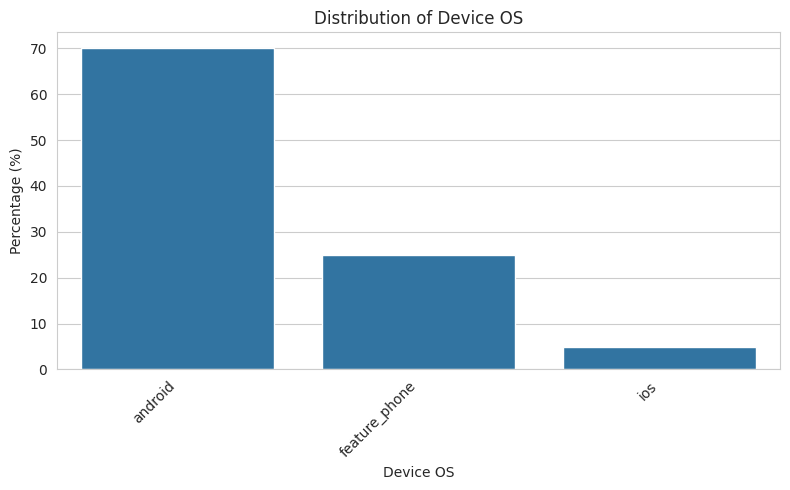

In [27]:
# Visualize distribution of device OS
plt.figure(figsize=(8, 5))
sns.barplot(x=device_os_percent.index, y=device_os_percent.values)
plt.title('Distribution of Device OS')
plt.xlabel('Device OS')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The distribution of device operating systems shows a strong dominance of Android, accounting for approximately 70% of all transactions. Feature phones represent a significant portion at around 25%, while iOS usage is relatively low at about 5%.

This distribution highlights a diverse user base, where a large majority rely on Android devices, likely due to their affordability and widespread availability. The substantial presence of feature phones indicates that a notable segment of users still depends on basic mobile devices, reinforcing the importance of USSD-based services for accessibility.

The relatively low share of iOS suggests limited adoption of higher-end devices within this ecosystem. Overall, the platform appears to cater primarily to a mass-market, mobile-first audience with varying levels of device capability.

## Analyze KYC Tiers

Examine the distribution of 'kyc_tier' to understand the level of verification among users and its potential implications on transaction behavior or other variables.

In [28]:
# Analyze frequency of each KYC tier
kyc_tier_counts = df_mobile_money['kyc_tier'].value_counts()
print("Frequency of each KYC tier:")
print(kyc_tier_counts)

kyc_tier_percent = (kyc_tier_counts / len(df_mobile_money)) * 100
print("\nPercentage distribution of each KYC tier:")
print(kyc_tier_percent.round(2))

Frequency of each KYC tier:
kyc_tier
tier1    2340195
tier2    1448278
tier3     211527
Name: count, dtype: int64

Percentage distribution of each KYC tier:
kyc_tier
tier1    58.50
tier2    36.21
tier3     5.29
Name: count, dtype: float64


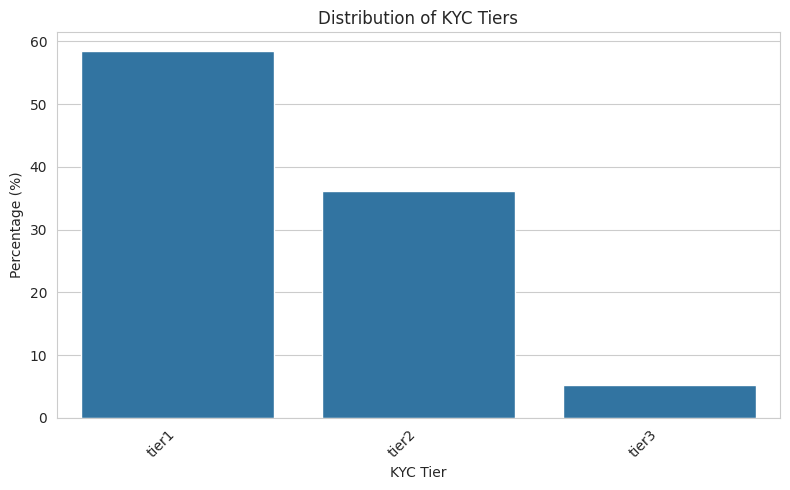

In [29]:
# Visualize distribution of KYC tiers
plt.figure(figsize=(8, 5))
sns.barplot(x=kyc_tier_percent.index, y=kyc_tier_percent.values)
plt.title('Distribution of KYC Tiers')
plt.xlabel('KYC Tier')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The distribution of KYC tiers shows that the majority of users are concentrated in lower verification levels, with Tier 1 accounting for approximately 58.5% and Tier 2 for around 36.2% of all users. In contrast, only about 5.3% of users fall into Tier 3, representing fully verified accounts.

This distribution suggests that most users operate within basic or intermediate verification levels, likely due to lower entry barriers and simpler onboarding requirements. The relatively small proportion of Tier 3 users indicates limited progression to full verification, which may be influenced by stricter documentation requirements or reduced necessity for higher-tier privileges among typical users.

Overall, the system appears to serve a broad base of lightly verified users, reinforcing its accessibility and inclusivity, while a smaller segment of fully verified users likely engages in higher-value or more regulated transactions.

## Analyze Fraud and Churn Flags

Assess the balance and distribution of the 'fraud_flag' and 'churn_30d' columns. This is crucial for understanding the prevalence of these events and for preparing for potential predictive modeling tasks.

In [30]:
# Analyze frequency of each fraud flag
fraud_flag_counts = df_mobile_money['fraud_flag'].value_counts()
print("Frequency of each fraud flag:")
print(fraud_flag_counts)

fraud_flag_percent = (fraud_flag_counts / len(df_mobile_money)) * 100
print("\nPercentage distribution of each fraud flag:")
print(fraud_flag_percent.round(2))

Frequency of each fraud flag:
fraud_flag
False    3940000
True       60000
Name: count, dtype: int64

Percentage distribution of each fraud flag:
fraud_flag
False    98.5
True      1.5
Name: count, dtype: float64


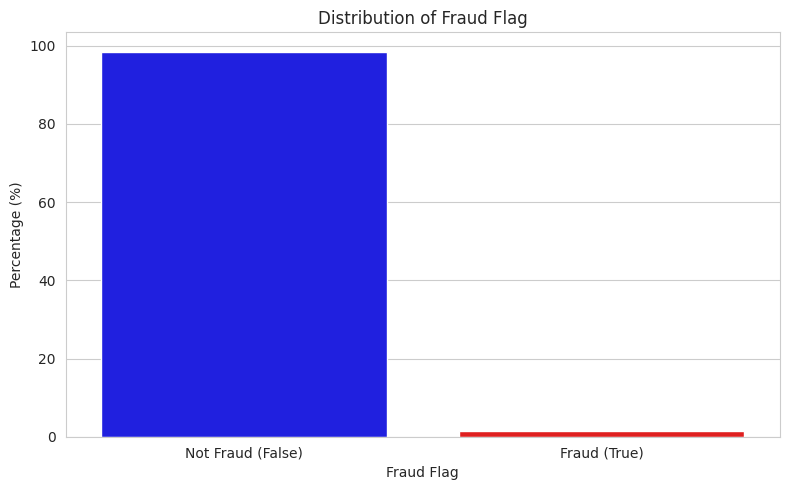

In [31]:
# Visualize distribution of fraud flags
plt.figure(figsize=(8, 5))
sns.barplot(x=fraud_flag_percent.index, y=fraud_flag_percent.values, hue=fraud_flag_percent.index, palette=['blue', 'red'], legend=False)
plt.title('Distribution of Fraud Flag')
plt.xlabel('Fraud Flag')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['Not Fraud (False)', 'Fraud (True)'], rotation=0)
plt.tight_layout()
plt.show()

The distribution of fraud flags is highly imbalanced, with approximately 98.5% of transactions labeled as non-fraudulent and only about 1.5% identified as fraudulent.

This indicates that fraudulent activity is relatively rare within the dataset.

In [32]:
# Analyze frequency of each churn_30d flag
churn_30d_counts = df_mobile_money['churn_30d'].value_counts()
print("Frequency of each churn_30d flag:")
print(churn_30d_counts)

churn_30d_percent = (churn_30d_counts / len(df_mobile_money)) * 100
print("\nPercentage distribution of each churn_30d flag:")
print(churn_30d_percent.round(2))

Frequency of each churn_30d flag:
churn_30d
False    3760000
True      240000
Name: count, dtype: int64

Percentage distribution of each churn_30d flag:
churn_30d
False    94.0
True      6.0
Name: count, dtype: float64


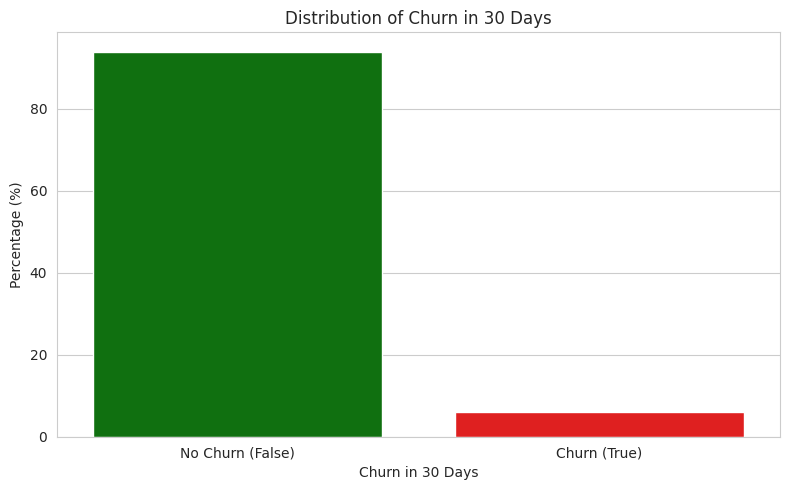

In [33]:
# Visualize distribution of churn_30d flags
plt.figure(figsize=(8, 5))
sns.barplot(x=churn_30d_percent.index, y=churn_30d_percent.values, hue=churn_30d_percent.index, palette=['green', 'red'], legend=False)
plt.title('Distribution of Churn in 30 Days')
plt.xlabel('Churn in 30 Days')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['No Churn (False)', 'Churn (True)'], rotation=0)
plt.tight_layout()
plt.show()

Approximately 6% of users churn within 30 days, while 94% remain active. This suggests generally strong short-term retention, but also highlights a meaningful segment of users who disengage early, offering opportunities for targeted retention strategies.

## Time-based Feature Engineering and Analysis

Extract relevant time-based features from the 'timestamp' column (e.g., hour of day, day of week, month, year) and analyze transaction trends and patterns over these time periods. Legends will be provided to ensure clarity of the plot.

In [34]:
# Create time-based features
df_mobile_money['timestamp'] = pd.to_datetime(df_mobile_money['timestamp'])

df_mobile_money['date'] = df_mobile_money['timestamp'].dt.date
df_mobile_money['hour'] = df_mobile_money['timestamp'].dt.hour
df_mobile_money['day_of_week_num'] = df_mobile_money['timestamp'].dt.dayofweek
df_mobile_money['day_of_week'] = df_mobile_money['timestamp'].dt.day_name()
df_mobile_money['month_num'] = df_mobile_money['timestamp'].dt.month
df_mobile_money['month'] = df_mobile_money['timestamp'].dt.month_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

df_mobile_money['day_of_week'] = pd.Categorical(
    df_mobile_money['day_of_week'],
    categories=weekday_order,
    ordered=True
)

df_mobile_money['month'] = pd.Categorical(
    df_mobile_money['month'],
    categories=month_order,
    ordered=True
)

print("Time-based features created successfully.")
display(df_mobile_money[['timestamp', 'date', 'hour', 'day_of_week', 'month']].head())

Time-based features created successfully.


,timestamp,date,hour,day_of_week,month
0,2024-06-03 20:35:00,2024-06-03,20,Monday,June
1,2024-04-01 08:34:00,2024-04-01,8,Monday,April
2,2024-01-08 19:17:00,2024-01-08,19,Monday,January
3,2024-04-14 23:10:00,2024-04-14,23,Sunday,April
4,2024-06-14 07:10:00,2024-06-14,7,Friday,June


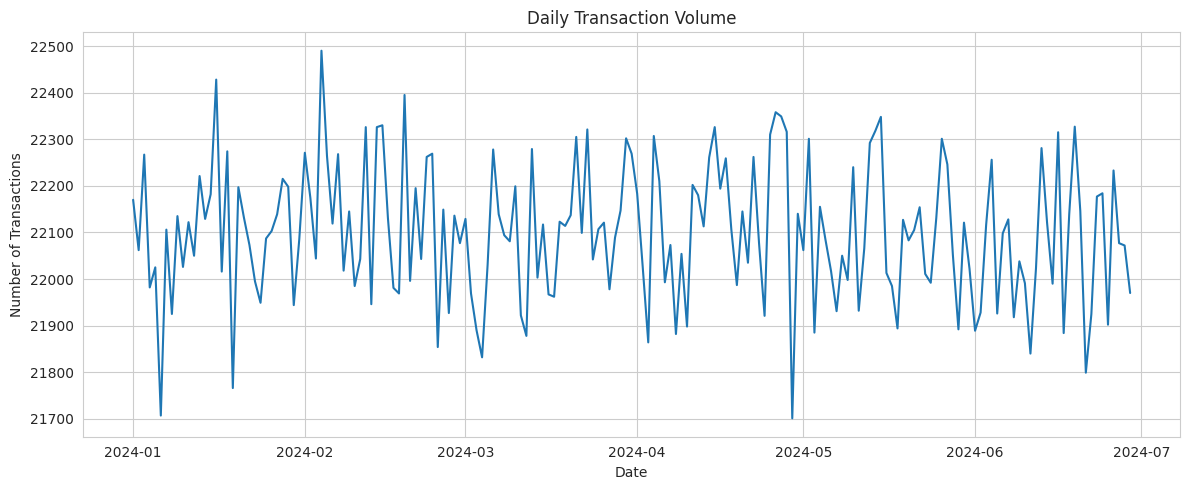

Peak transaction day: 2024-02-04 with 22,490 transactions
Lowest transaction day: 2024-04-29 with 21,701 transactions


In [35]:
# Daily transaction count trend
daily_txn_count = df_mobile_money.groupby('date').size()

plt.figure(figsize=(12, 5))
daily_txn_count.plot()
plt.title('Daily Transaction Volume')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

print(f"Peak transaction day: {daily_txn_count.idxmax()} with {daily_txn_count.max():,} transactions")
print(f"Lowest transaction day: {daily_txn_count.idxmin()} with {daily_txn_count.min():,} transactions")

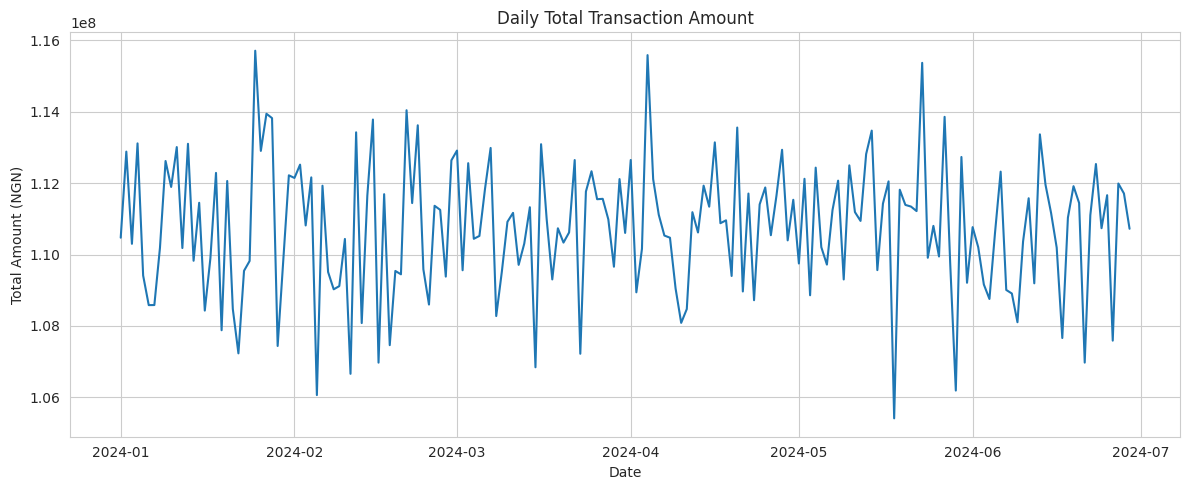

Peak amount day: 2024-01-25 with NGN 115,704,450.00
Lowest amount day: 2024-05-18 with NGN 105,415,550.00


In [36]:
# Daily total transaction amount trend
daily_total_amount = df_mobile_money.groupby('date')['amount_ngn'].sum()

plt.figure(figsize=(12, 5))
daily_total_amount.plot()
plt.title('Daily Total Transaction Amount')
plt.xlabel('Date')
plt.ylabel('Total Amount (NGN)')
plt.tight_layout()
plt.show()

print(f"Peak amount day: {daily_total_amount.idxmax()} with NGN {daily_total_amount.max():,.2f}")
print(f"Lowest amount day: {daily_total_amount.idxmin()} with NGN {daily_total_amount.min():,.2f}")

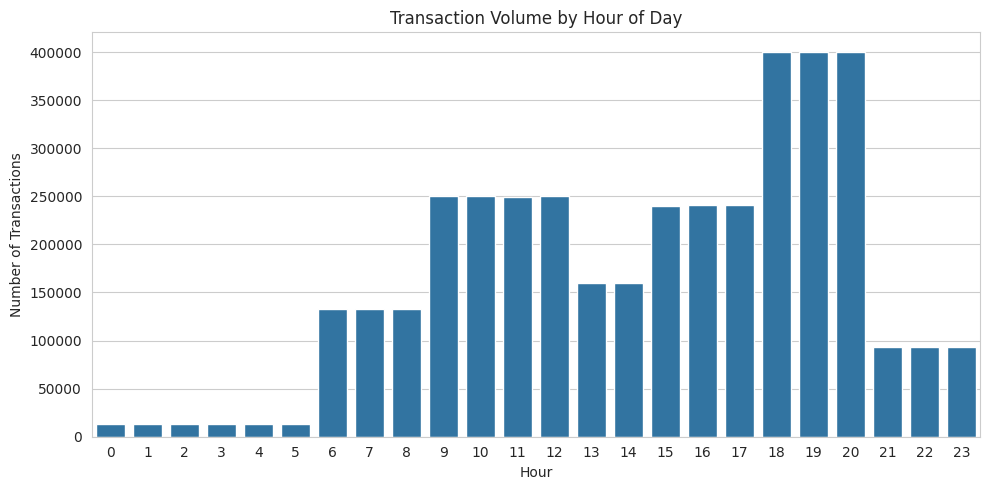

Peak hour: 19:00 with 400,474 transactions


In [37]:
# Hourly transaction activity
hourly_counts = df_mobile_money.groupby('hour').size()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values)
plt.title('Transaction Volume by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

peak_hour = hourly_counts.idxmax()
print(f"Peak hour: {peak_hour}:00 with {hourly_counts.max():,} transactions")

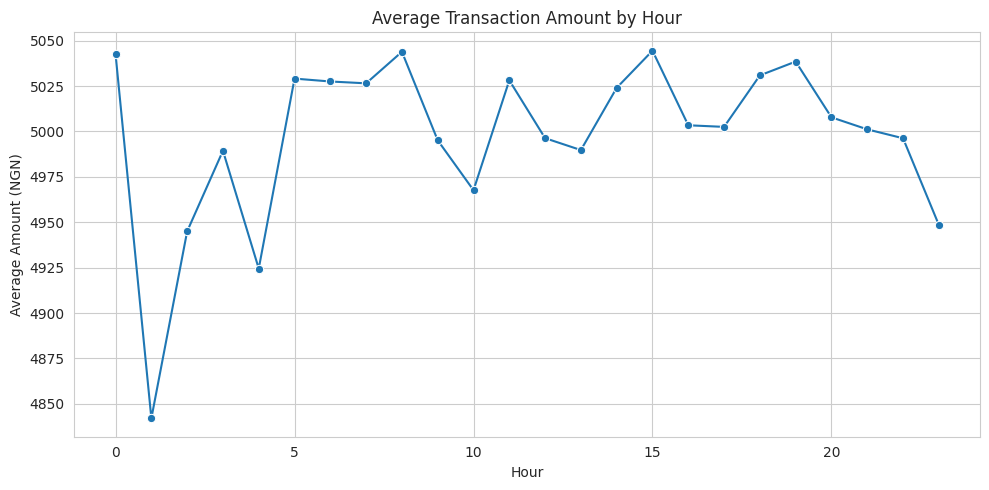

In [38]:
# Average transaction amount by hour
hourly_avg_amount = df_mobile_money.groupby('hour')['amount_ngn'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_avg_amount.index, y=hourly_avg_amount.values, marker='o')
plt.title('Average Transaction Amount by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Amount (NGN)')
plt.tight_layout()
plt.show()

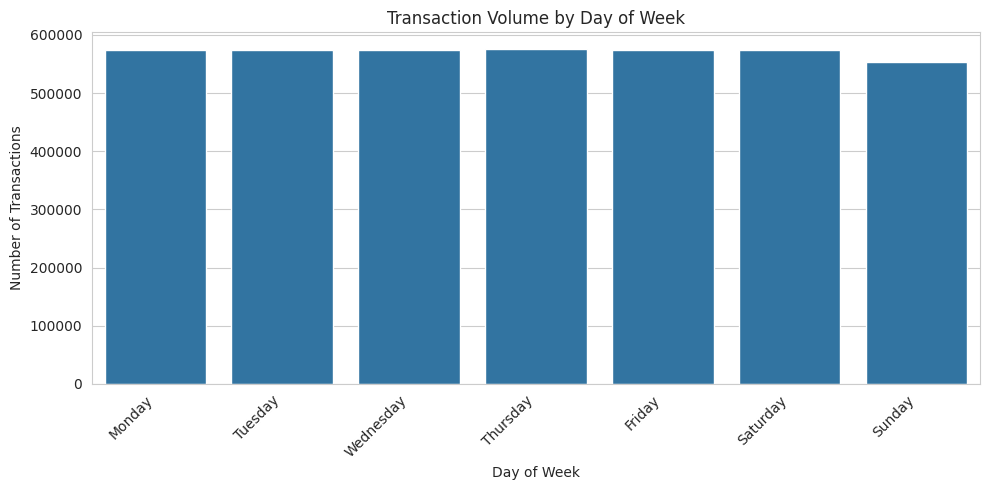

Most active weekday: Thursday with 575,711 transactions
Least active weekday: Sunday with 553,021 transactions


In [39]:
# Transaction volume by day of week
weekday_counts = df_mobile_money.groupby('day_of_week', observed=False).size().reindex(weekday_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values)
plt.title('Transaction Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Most active weekday: {weekday_counts.idxmax()} with {weekday_counts.max():,} transactions")
print(f"Least active weekday: {weekday_counts.idxmin()} with {weekday_counts.min():,} transactions")

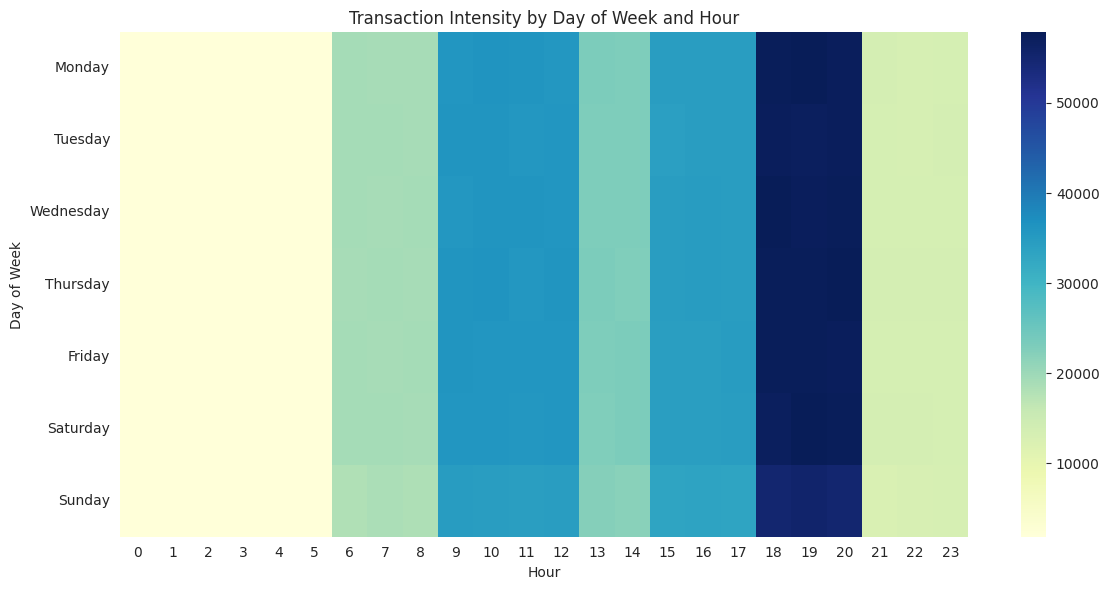

In [40]:
# Day-of-week vs hour-of-day heatmap
weekday_hour_heatmap = (
    df_mobile_money.groupby(['day_of_week', 'hour'], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(weekday_order)
)

plt.figure(figsize=(12, 6))
sns.heatmap(weekday_hour_heatmap, cmap='YlGnBu')
plt.title('Transaction Intensity by Day of Week and Hour')
plt.xlabel('Hour')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

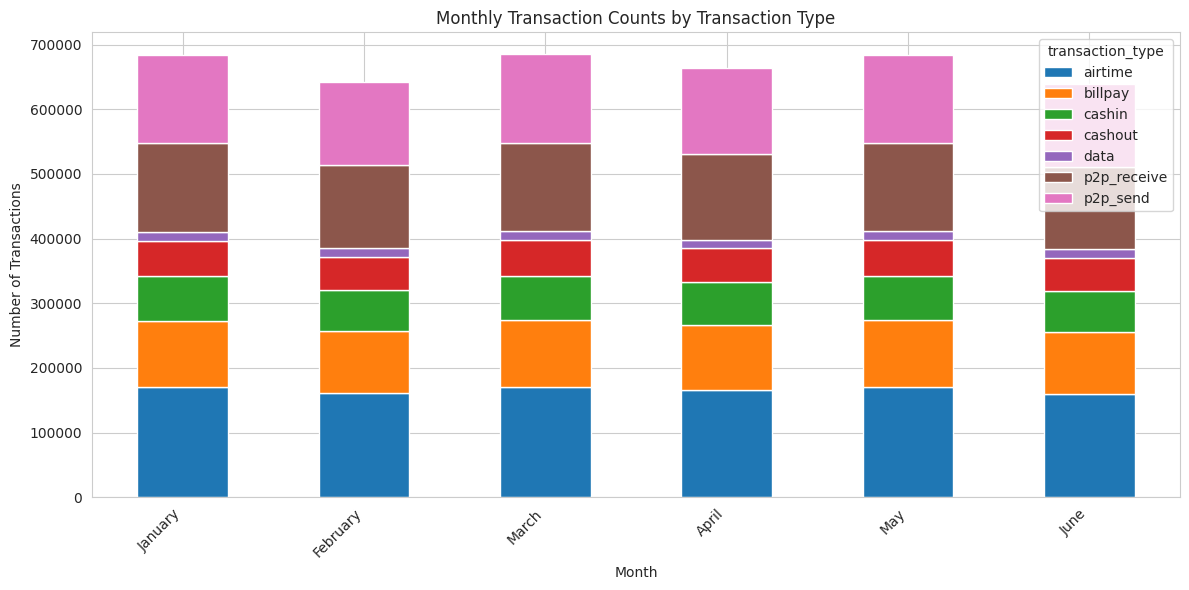

In [41]:
# Monthly transaction counts by transaction type
monthly_type_counts = (
    pd.crosstab(df_mobile_money['month'], df_mobile_money['transaction_type'])
    .reindex(month_order)
    .dropna(how='all')
)

monthly_type_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Monthly Transaction Counts by Transaction Type')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This section helps answer questions such as:

- Are transactions evenly distributed over time or concentrated in specific periods?
- Which hours and weekdays are busiest?
- Do certain transaction types spike in specific months?
- Are there operational periods where support capacity, fraud controls, or system scaling should be strengthened?

## Correlation Analysis

Calculate and visualize the correlation matrix for numerical features to identify strong relationships between variables. This will help in understanding potential multicollinearity or dependencies.

In [42]:
# Prepare numeric features for correlation analysis
corr_df = df_mobile_money.copy()

corr_df['fraud_flag_int'] = corr_df['fraud_flag'].astype(int)
corr_df['churn_30d_int'] = corr_df['churn_30d'].astype(int)

numeric_cols = [
    'amount_ngn',
    'fee_ngn',
    'balance_after_ngn',
    'hour',
    'day_of_week_num',
    'month_num',
    'fraud_flag_int',
    'churn_30d_int'
]

corr_matrix = corr_df[numeric_cols].corr()
display(corr_matrix.round(3))

,amount_ngn,fee_ngn,balance_after_ngn,hour,day_of_week_num,month_num,fraud_flag_int,churn_30d_int
amount_ngn,1.000,0.672,-0.000,0.000,0.000,0.000,0.016,-0.069
fee_ngn,0.672,1.000,0.001,0.001,-0.001,0.000,0.021,-0.106
balance_after_ngn,-0.000,0.001,1.000,0.000,-0.001,-0.000,0.001,-0.012
hour,0.000,0.001,0.000,1.000,0.001,-0.000,-0.000,0.001
day_of_week_num,0.000,-0.001,-0.001,0.001,1.000,0.024,0.001,-0.000
month_num,0.000,0.000,-0.000,-0.000,0.024,1.000,0.001,-0.001
fraud_flag_int,0.016,0.021,0.001,-0.000,0.001,0.001,1.000,-0.028
churn_30d_int,-0.069,-0.106,-0.012,0.001,-0.000,-0.001,-0.028,1.000


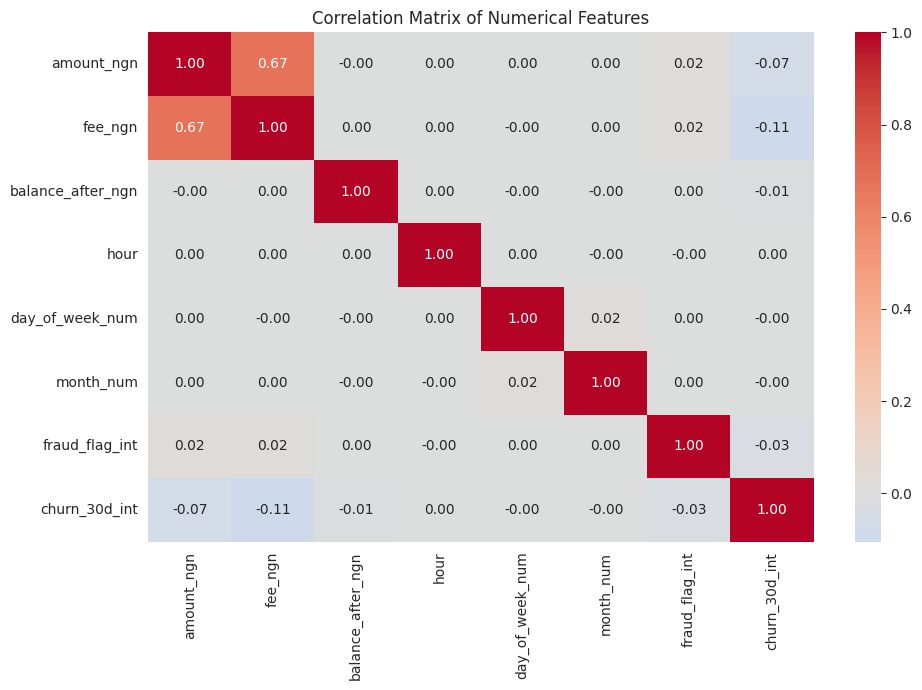

In [43]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [44]:
# Strongest correlation pairs
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Top correlation pairs:")
display(corr_pairs.to_frame(name='correlation').head(10))

Top correlation pairs:


correlation
amount_ngn        fee_ngn            0.672287
fee_ngn           churn_30d_int     -0.105699
amount_ngn        churn_30d_int     -0.069072
fraud_flag_int    churn_30d_int     -0.027583
day_of_week_num   month_num          0.023601
fee_ngn           fraud_flag_int     0.020752
amount_ngn        fraud_flag_int     0.015918
balance_after_ngn churn_30d_int     -0.011562
                  fraud_flag_int     0.000790
fee_ngn           hour               0.000785

## Summary

In [45]:
# Programmatic summary of key findings
summary_lines = []

summary_lines.append(f"Dataset size: {len(df_mobile_money):,} transactions")
summary_lines.append(f"Unique wallets: {df_mobile_money['wallet_id'].nunique():,}")
summary_lines.append(
    f"Date range: {df_mobile_money['timestamp'].min().date()} to {df_mobile_money['timestamp'].max().date()}"
)

top_tx_type = df_mobile_money['transaction_type'].value_counts(normalize=True).mul(100).round(2)
top_channel = df_mobile_money['channel'].value_counts(normalize=True).mul(100).round(2)
top_device = df_mobile_money['device_os'].value_counts(normalize=True).mul(100).round(2)
top_kyc = df_mobile_money['kyc_tier'].value_counts(normalize=True).mul(100).round(2)

summary_lines.append(
    f"Top transaction type: {top_tx_type.idxmax()} ({top_tx_type.max():.2f}%)"
)
summary_lines.append(
    f"Top channel: {top_channel.idxmax()} ({top_channel.max():.2f}%)"
)
summary_lines.append(
    f"Top device OS: {top_device.idxmax()} ({top_device.max():.2f}%)"
)
summary_lines.append(
    f"Top KYC tier: {top_kyc.idxmax()} ({top_kyc.max():.2f}%)"
)

summary_lines.append(
    f"Fraud rate: {df_mobile_money['fraud_flag'].mean() * 100:.2f}%"
)
summary_lines.append(
    f"30-day churn rate: {df_mobile_money['churn_30d'].mean() * 100:.2f}%"
)

peak_hour = df_mobile_money.groupby('hour').size().idxmax()
peak_day = df_mobile_money.groupby('day_of_week', observed=False).size().reindex(weekday_order).idxmax()

summary_lines.append(f"Peak transaction hour: {peak_hour}:00")
summary_lines.append(f"Most active weekday: {peak_day}")

print("Key Findings")
print("=" * 60)
for line in summary_lines:
    print(f"- {line}")

Key Findings
- Dataset size: 4,000,000 transactions
- Unique wallets: 375,837
- Date range: 2024-01-01 to 2024-06-29
- Top transaction type: airtime (24.95%)
- Top channel: ussd (50.07%)
- Top device OS: android (69.99%)
- Top KYC tier: tier1 (58.50%)
- Fraud rate: 1.50%
- 30-day churn rate: 6.00%
- Peak transaction hour: 19:00
- Most active weekday: Thursday


### Final EDA Takeaways

- The dataset is large, clean, and suitable for analysis, with no missing values in core fields and no duplicate rows.
- Empty `agent_id` values appear to be expected behavior rather than a data quality problem, since most transactions are not agent-assisted.
- Transaction amounts and fees are both strongly right-skewed, with clear evidence of discrete pricing tiers and a fee cap.
- The platform is clearly mobile-first, with transactions dominated by USSD and app channels, and by Android and feature phones.
- Most users belong to lower KYC tiers, which suggests the service prioritizes accessibility and low-friction onboarding.
- Fraud is rare and churn is modest, so any future predictive modeling will need to address class imbalance.
- Time-based analysis, segment-level risk analysis, and the correlation matrix provide a strong foundation for later feature engineering and model building.